<a href="https://colab.research.google.com/github/RianEK0/blockchain/blob/main/kuburan_batu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# Analisis Sentimen Ulasan "Kuburan Batu Lemo Toraja"

Proyek ini bertujuan untuk melakukan analisis sentimen terhadap ulasan atau komentar mengenai destinasi wisata "Kuburan Batu Lemo Toraja". Data akan disimulasikan dari berbagai platform media sosial, kemudian diproses, dianalisis sentimennya, dan divisualisasikan.
```

```markdown
## 1. Data Collection (Simulasi Data Realistis)

Karena keterbatasan akses langsung ke API atau scraping skala besar dari berbagai platform secara real-time, kita akan menyimulasikan data ulasan. Simulasi ini akan mencakup username yang realistis dan unik, tanggal acak, isi komentar yang bervariasi (positif, negatif, netral) terkait topik, dan penanda platform.
```

In [17]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# --- 2. Username (PENTING) ---
def generate_random_username():
    # Kumpulan kata dan nama yang bisa digunakan untuk username
    first_names = ['andi', 'budi', 'cita', 'dani', 'eka', 'fajar', 'gina', 'harry', 'indah', 'joko', 'kiki', 'lisa']
    last_names = ['pratama', 'wijaya', 'sari', 'nugroho', 'dewi', 'setiawan', 'rahman', 'putri', 'lestari', 'hidayat']
    adjectives = ['traveller', 'explorer', 'adventure', 'journey', 'wanderlust', 'backpacker', 'holiday']
    numbers = [str(i) for i in range(100, 999)]
    symbols = ['', '_', '.']

    parts = []
    # Memilih 2 hingga 3 bagian untuk username
    num_parts = random.choice([2, 3])

    # Bagian pertama biasanya nama atau kata unik
    parts.append(random.choice(first_names + adjectives))

    if num_parts == 2:
        # Bagian kedua bisa nama belakang, angka, atau kata unik lain
        parts.append(random.choice(last_names + numbers + adjectives))
    else: # num_parts == 3
        # Bagian kedua nama belakang atau kata unik, bagian ketiga angka
        parts.append(random.choice(last_names + adjectives))
        parts.append(random.choice(numbers))

    # Menggabungkan dengan simbol acak atau tanpa simbol
    separator = random.choice(symbols)
    username = separator.join(parts)

    # Tambahkan angka acak di akhir untuk meningkatkan keunikan jika kurang
    if random.random() < 0.3: # 30% chance to add more numbers
        username += str(random.randint(0, 99))

    # Kadang ubah case untuk variasi
    if random.random() < 0.2: username = username.upper()
    elif random.random() < 0.4: username = username.capitalize()

    return username.lower().replace(' ', '') # Pastikan lowercase dan tanpa spasi

# Kumpulan komentar untuk simulasi (positif, negatif, netral) terkait Lemo Toraja
# Saya coba masukkan variasi opini seperti keindahan, akses, pengalaman, harga, suasana
positive_comments = [
    "Kuburan Batu Lemo Toraja ini sungguh menakjubkan! Pemandangan patung-patung Tau-tau di tebing batu sangat unik dan artistik. Pengalaman budaya yang luar biasa! 👍",
    "Akses menuju Lemo cukup mudah, jalannya bagus. Tempatnya bersih dan terawat. Budayanya kental, sangat recommended untuk pecinta sejarah dan seni. Pengalaman yang tak terlupakan.",
    "Tau-taunya bener-bener keren! Banyak nilai sejarah dan cerita di baliknya. Suasana di sana tenang dan syahdu. Harga tiketnya pun terjangkau untuk keindahan yang ditawarkan.",
    "Sangat terkesan dengan keunikan makam tebing di Lemo. Guide lokalnya juga informatif, menjelaskan makna di balik setiap patung. Ini harus jadi daftar wajib kalau ke Toraja.",
    "Pengalaman wisata yang mendidik dan memukau. Kualitas pahatan batunya luar biasa. Meskipun ramai, suasananya tetap terjaga. Salah satu situs budaya terbaik di Indonesia.",
    "Lemo itu hidden gem di Toraja! Walaupun sedikit menanjak, tapi pemandangannya sepadan. Harga tiket sangat wajar. Saya pasti akan kembali lagi suatu saat nanti. ❤️",
    "Keindahan budaya Toraja terpancar jelas di Lemo. Unik, magis, dan sangat berkesan. Akses jalan sudah cukup baik. Pelayanan di sekitar juga ramah."
    "Makam batu Lemo sangat ikonik. Pengalaman yang tak terlupakan melihat langsung bagaimana leluhur Toraja menghormati arwah mereka. Sangat direkomendasikan.",
    "Luar biasa! Arsitektur makam tebing yang menawan dan patung-patung Tau-tau yang artistik. Pengalaman yang sangat kaya budaya dan layak untuk dikunjungi.",
    "Sangat terpukau dengan keunikan Lemo. Suasananya sakral tapi juga menenangkan. Pemandangan alam di sekitarnya juga indah. Benar-benar destinasi yang memuaskan."
]

negative_comments = [
    "Jalan menuju Kuburan Batu Lemo agak sempit dan kurang nyaman untuk mobil besar. Harga tiket lumayan mahal untuk kunjungan yang singkat. Kurang puas dengan fasilitasnya. 👎",
    "Agak kecewa dengan jumlah penjual souvenir yang terlalu banyak dan memaksa. Mengganggu ketenangan tempat sakral seperti ini. Pengalaman jadi kurang maksimal.",
    "Tau-taunya banyak yang sudah rusak dan kurang terawat. Kurang ada penjelasan detail tentang sejarahnya. Padahal potensinya besar sekali. Pengelolaan harus ditingkatkan.",
    "Lemo cukup ramai dan panas terik saat saya datang. Kurang nyaman untuk menikmati suasana. Mungkin butuh lebih banyak tempat teduh. Akses parkir juga terbatas.",
    "Sepertinya kurang promosi dan informasi yang jelas. Banyak turis yang bingung. Padahal tempatnya historis, sayang kalau tidak dikelola lebih baik. Harga makanan di sekitar juga lumayan tinggi.",
    "Terlalu banyak sampah di beberapa sudut, padahal ini situs budaya penting. Pengalaman jadi sedikit terganggu. Semoga pengelola lebih perhatian lagi. 😒",
    "Aksesibilitas kurang baik untuk lansia atau penyandang disabilitas. Banyak tangga curam dan tidak ada fasilitas pendukung. Ini perlu diperbaiki untuk inklusivitas."
    "Harga tiket masuknya lumayan, tapi fasilitas toilet umum kurang bersih. Agak mengecewakan untuk tempat wisata sebesar ini.",
    "Lemo itu cuma ramai di awal saja, setelah masuk ke dalam kurang terarah. Patung-patung Tau-tau juga banyak yang sudah pudar. Perlu restorasi serius nih.",
    "Sudah bayar mahal tapi rasanya kurang worth it. Penjelasan kurang, penjual memaksa, dan suasana terlalu komersil. Hilang kesan sakralnya."
]

neutral_comments = [
    "Kuburan Batu Lemo lumayan unik, tapi tidak jauh berbeda dengan makam tebing lain di Toraja. Cukup bagus untuk dilihat sekali saja. Suasananya biasa saja.",
    "Akses ke Lemo cukup mudah, tapi fasilitasnya standar. Tidak ada yang istimewa, tidak juga buruk. Sekadar tempat wisata pada umumnya.",
    "Tau-taunya menarik, tapi tidak terlalu banyak yang bisa dieksplorasi. Cukup sebentar saja di sana. Harga tiketnya sesuai lah.",
    "Tempatnya ok, tapi kalau sudah pernah lihat makam Toraja yang lain, mungkin tidak terlalu wow. Pengalaman yang cukup netral.",
    "Suasana di Lemo cukup ramai, tapi masih bisa menikmati. Tidak ada keluhan khusus, tapi juga tidak ada yang bikin terkesan luar biasa. Hanya mampir lewat.",
    "Lemo ya Lemo, begitu saja. Tidak ada yang spesial, tapi juga tidak jelek. Cukup untuk mengisi waktu liburan. Parkir lumayan sulit dicari.",
    "Makam batunya menarik. Sudah banyak yang tahu tempat ini. Cukup ramai pengunjung. Tidak ada yang perlu dikeluhkan, tapi juga bukan yang terbaik."
    "Ini salah satu destinasi di Toraja. Mirip dengan tempat makam tebing lainnya. Cukup untuk menambah pengalaman.",
    "Lemo punya nilai sejarah, tapi penataannya standar. Tidak ada hal baru yang ditemukan. Oke saja.",
    "Tidak ada ekspektasi khusus saat datang ke Lemo. Dan memang sesuai ekspektasi, cukup unik tapi tidak terlalu membuat kagum."
]

platforms = ['Google Reviews', 'Instagram', 'X/Twitter', 'TikTok']

def generate_review_data(num_reviews=500):
    data = []
    unique_usernames = set()
    start_date = datetime(2023, 1, 1)
    end_date = datetime(2024, 6, 30)

    while len(data) < num_reviews:
        username = generate_random_username()
        if username in unique_usernames:
            continue # Pastikan username unik
        unique_usernames.add(username)

        # Random date within the range
        random_days = random.randint(0, (end_date - start_date).days)
        date = start_date + timedelta(days=random_days)

        platform = random.choice(platforms)

        # Randomly pick comment sentiment
        comment_type = random.choices(['positive', 'negative', 'neutral'], weights=[0.5, 0.2, 0.3], k=1)[0]
        if comment_type == 'positive':
            comment = random.choice(positive_comments)
        elif comment_type == 'negative':
            comment = random.choice(negative_comments)
        else:
            comment = random.choice(neutral_comments)

        # Tambahkan sedikit variasi agar komentar tidak persis sama
        comment += random.choice(['', ' (mantap!)', ' (harus coba)', ' (cukup)', ' (duh!)', ' (oke lah)', ' (kurang)']) if random.random() < 0.2 else ''

        data.append({
            'username': username,
            'tanggal': date.strftime('%Y-%m-%d'),
            'isi_komentar': comment,
            'platform': platform
        })

    return pd.DataFrame(data)

# Generate 550 reviews to ensure at least 500 unique after filtering/etc.
# User minta minimal 500 data, jadi kita buat agak lebih sedikit.
df_reviews = generate_review_data(num_reviews=550)

print(f"Total data review yang dihasilkan: {len(df_reviews)}")
print("5 data teratas:")
display(df_reviews.head())
print("\nInformasi DataFrame:")
df_reviews.info()

Total data review yang dihasilkan: 550
5 data teratas:


,username,tanggal,isi_komentar,platform
0,gina.667,2023-11-17,Kuburan Batu Lemo Toraja ini sungguh menakjubk...,X/Twitter
1,wanderlust_lestari_53416,2023-05-01,Kuburan Batu Lemo Toraja ini sungguh menakjubk...,Instagram
2,eka93563,2023-10-10,Kuburan Batu Lemo Toraja ini sungguh menakjubk...,Google Reviews
3,fajar_22885,2024-03-31,"Akses menuju Lemo cukup mudah, jalannya bagus....",X/Twitter
4,travellerholiday832,2023-06-22,Tau-taunya bener-bener keren! Banyak nilai sej...,Google Reviews



Informasi DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   username      550 non-null    object
 1   tanggal       550 non-null    object
 2   isi_komentar  550 non-null    object
 3   platform      550 non-null    object
dtypes: object(4)
memory usage: 17.3+ KB


```markdown
## 3. Data Preprocessing

Tahap ini meliputi pembersihan teks dari noise (emoji, URL, simbol, angka), case folding, tokenization, penghapusan stopword (kata-kata umum yang tidak relevan untuk analisis sentimen), dan stemming (mengubah kata menjadi bentuk dasarnya).
```

In [20]:
import re
import nltk
from nltk.tokenize import word_tokenize

# Instal Sastrawi jika belum terinstal dan impor setelahnya
try:
    import Sastrawi
except ModuleNotFoundError:
    print("Sastrawi not found. Installing...")
    !pip install Sastrawi
    print("Sastrawi installed.")

# Sekarang impor komponen Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Pastikan resource NLTK sudah diunduh
try:
    nltk.data.find('tokenizers/punkt')
except LookupError: # Correct exception to catch for missing NLTK data
    print("NLTK 'punkt' tokenizer not found. Downloading...")
    nltk.download('punkt')
    print("NLTK 'punkt' tokenizer downloaded.")

# Add download for 'punkt_tab' as indicated by the error message
try:
    nltk.data.find('tokenizers/punkt_tab') # Check if punkt_tab is already downloaded
except LookupError:
    print("NLTK 'punkt_tab' resource not found. Downloading...")
    nltk.download('punkt_tab')
    print("NLTK 'punkt_tab' resource downloaded.")

# Inisialisasi Sastrawi Stemmer dan Stopword Remover
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

factory_stopword = StopWordRemoverFactory()
stopword_remover = factory_stopword.create_stop_word_remover()

# Menggunakan stopword bawaan Sastrawi dan bisa ditambahkan secara manual jika perlu
list_stopwords = factory_stopword.get_stop_words() # Ambil daftar stopword standar Bahasa Indonesia
# list_stopwords.extend(['yg', 'ga', 'gak', 'nya', 'sih', 'udah', 'bgt']) # Contoh penambahan manual

def clean_text(text):
    # 1. Hapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 2. Hapus emoji (regex untuk emoji)
    emoji_pattern = re.compile(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF\U00002702-\U000027B0\U000024C2-\U0001F251]+', flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    # 3. Hapus simbol dan angka, hanya sisakan huruf dan spasi
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 4. Case Folding (ubah ke huruf kecil semua)
    text = text.lower()
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_text(text):
    # 1. Cleaning dan Case Folding sudah dilakukan di clean_text
    text = clean_text(text)
    # 2. Tokenization
    tokens = word_tokenize(text)
    # 3. Stopword Removal
    tokens_no_stopwords = [word for word in tokens if word not in list_stopwords]
    # 4. Stemming
    stemmed_tokens = [stemmer.stem(word) for word in tokens_no_stopwords]
    return ' '.join(stemmed_tokens)

print("Mulai preprocessing data...")
df_reviews['processed_text'] = df_reviews['isi_komentar'].apply(preprocess_text)
print("Preprocessing selesai!\n")

print("Contoh data setelah preprocessing:")
display(df_reviews[['isi_komentar', 'processed_text']].head())

NLTK 'punkt_tab' resource not found. Downloading...
NLTK 'punkt_tab' resource downloaded.
Mulai preprocessing data...


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Preprocessing selesai!

Contoh data setelah preprocessing:


,isi_komentar,processed_text
0,Kuburan Batu Lemo Toraja ini sungguh menakjubk...,kubur batu lemo toraja sungguh takjub pandang ...
1,Kuburan Batu Lemo Toraja ini sungguh menakjubk...,kubur batu lemo toraja sungguh takjub pandang ...
2,Kuburan Batu Lemo Toraja ini sungguh menakjubk...,kubur batu lemo toraja sungguh takjub pandang ...
3,"Akses menuju Lemo cukup mudah, jalannya bagus....",akses tuju lemo cukup mudah jalan bagus tempat...
4,Tau-taunya bener-bener keren! Banyak nilai sej...,tautaunya benerbener keren banyak nilai sejara...


```markdown
## 4. Sentiment Analysis (Lexicon-Based)

Untuk analisis sentimen, kita akan menggunakan pendekatan berbasis leksikon sederhana. Kita akan mendefinisikan beberapa kata kunci positif dan negatif dalam Bahasa Indonesia. Sentimen akan ditentukan berdasarkan keberadaan dan jumlah kata-kata ini dalam teks yang sudah diproses.
```

In [21]:
# Lexicon sederhana untuk sentimen Bahasa Indonesia
# Ini bisa diperkaya lagi dengan kamus sentimen yang lebih komprehensif
positive_words = [
    'menakjubkan', 'unik', 'artistik', 'luar biasa', 'recommended', 'tak terlupakan',
    'indah', 'bagus', 'terawat', 'bersih', 'kental', 'mendidik', 'memukau', 'keren',
    'worth it', 'puas', 'ramah', 'nyaman', 'historis', 'magis', 'berkesan', 'menawan',
    'ikonik', 'terpukau', 'memuaskan', 'menenangkan', 'terjangkau', 'baik', 'oke'
]

negative_words = [
    'sempit', 'kurang nyaman', 'mahal', 'kecewa', 'mengganggu', 'rusak', 'kurang terawat',
    'panas', 'ramai', 'kurang promosi', 'terbatas', 'sampah', 'terganggu', 'mengecewakan',
    'pudar', 'komersil', 'buruk', 'sulit', 'tidak worth it', 'jelek', 'kurang puas'
]

def analyze_sentiment_lexicon(text):
    score_positive = sum(1 for word in text.split() if word in positive_words)
    score_negative = sum(1 for word in text.split() if word in negative_words)

    if score_positive > score_negative:
        return 'Positif'
    elif score_negative > score_positive:
        return 'Negatif'
    else:
        return 'Netral'

print("Mulai analisis sentimen...")
df_reviews['sentiment'] = df_reviews['processed_text'].apply(analyze_sentiment_lexicon)
print("Analisis sentimen selesai!\n")

print("Contoh data dengan sentimen:")
display(df_reviews[['isi_komentar', 'processed_text', 'sentiment']].head())

Mulai analisis sentimen...
Analisis sentimen selesai!

Contoh data dengan sentimen:


,isi_komentar,processed_text,sentiment
0,Kuburan Batu Lemo Toraja ini sungguh menakjubk...,kubur batu lemo toraja sungguh takjub pandang ...,Positif
1,Kuburan Batu Lemo Toraja ini sungguh menakjubk...,kubur batu lemo toraja sungguh takjub pandang ...,Positif
2,Kuburan Batu Lemo Toraja ini sungguh menakjubk...,kubur batu lemo toraja sungguh takjub pandang ...,Positif
3,"Akses menuju Lemo cukup mudah, jalannya bagus....",akses tuju lemo cukup mudah jalan bagus tempat...,Positif
4,Tau-taunya bener-bener keren! Banyak nilai sej...,tautaunya benerbener keren banyak nilai sejara...,Positif


```markdown
## 5. Data Integration

Data sudah terintegrasi ke dalam satu DataFrame `df_reviews` sejak awal simulasi, dengan kolom `platform` dan `sentiment` sudah ditambahkan pada tahap sebelumnya. Ini memudahkan untuk langsung masuk ke visualisasi.
```

In [12]:
print("Data terintegrasi siap untuk visualisasi:")
display(df_reviews.head())

Data terintegrasi siap untuk visualisasi:


,username,tanggal,isi_komentar,platform
0,joko_wijaya_364,2023-12-17,Luar biasa! Arsitektur makam tebing yang menaw...,Instagram
1,cita.sari.84380,2023-07-17,Keindahan budaya Toraja terpancar jelas di Lem...,TikTok
2,journey_lestari_411,2024-05-29,"Akses menuju Lemo cukup mudah, jalannya bagus....",TikTok
3,kikiwanderlust147,2024-05-28,Luar biasa! Arsitektur makam tebing yang menaw...,TikTok
4,indah.backpacker.307,2024-02-15,Sangat terpukau dengan keunikan Lemo. Suasanan...,Google Reviews


```markdown
## 6. Visualisasi Data

Kita akan membuat beberapa visualisasi untuk memahami distribusi sentimen secara keseluruhan, sentimen berdasarkan platform, dan kata-kata yang paling sering muncul dalam ulasan.
```

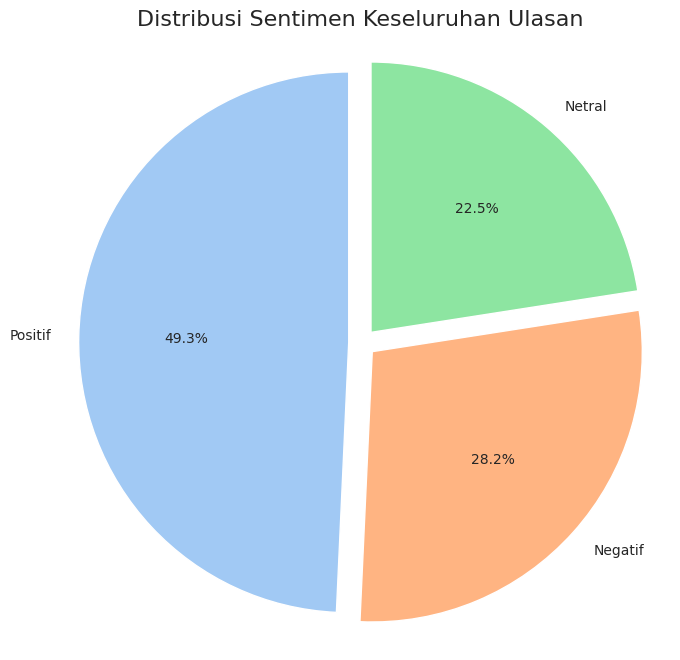

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style("whitegrid")

# 1. Pie Chart Distribusi Sentimen
plt.figure(figsize=(8, 8))
sentiment_counts = df_reviews['sentiment'].value_counts()
colors = sns.color_palette('pastel')[0:3] # Warna yang sedikit soft
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0.05, 0.05))
plt.title('Distribusi Sentimen Keseluruhan Ulasan', fontsize=16)
plt.axis('equal') # Memastikan pie chart berbentuk lingkaran sempurna
plt.show()

<Figure size 1200x700 with 0 Axes>

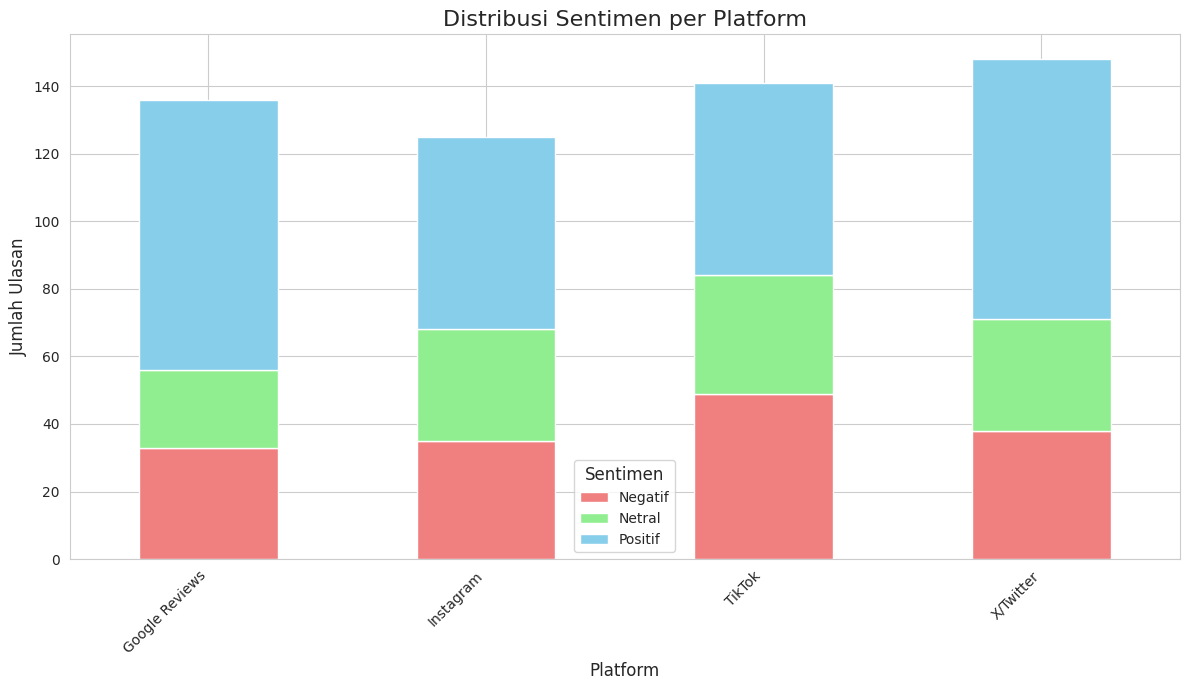

In [23]:
# 2. Bar Chart Sentimen per Platform
plt.figure(figsize=(12, 7))
sentiment_platform = df_reviews.groupby(['platform', 'sentiment']).size().unstack(fill_value=0)
sentiment_platform.plot(kind='bar', stacked=True, figsize=(12, 7), color=['lightcoral', 'lightgreen', 'skyblue'])
plt.title('Distribusi Sentimen per Platform', fontsize=16)
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Sentimen', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

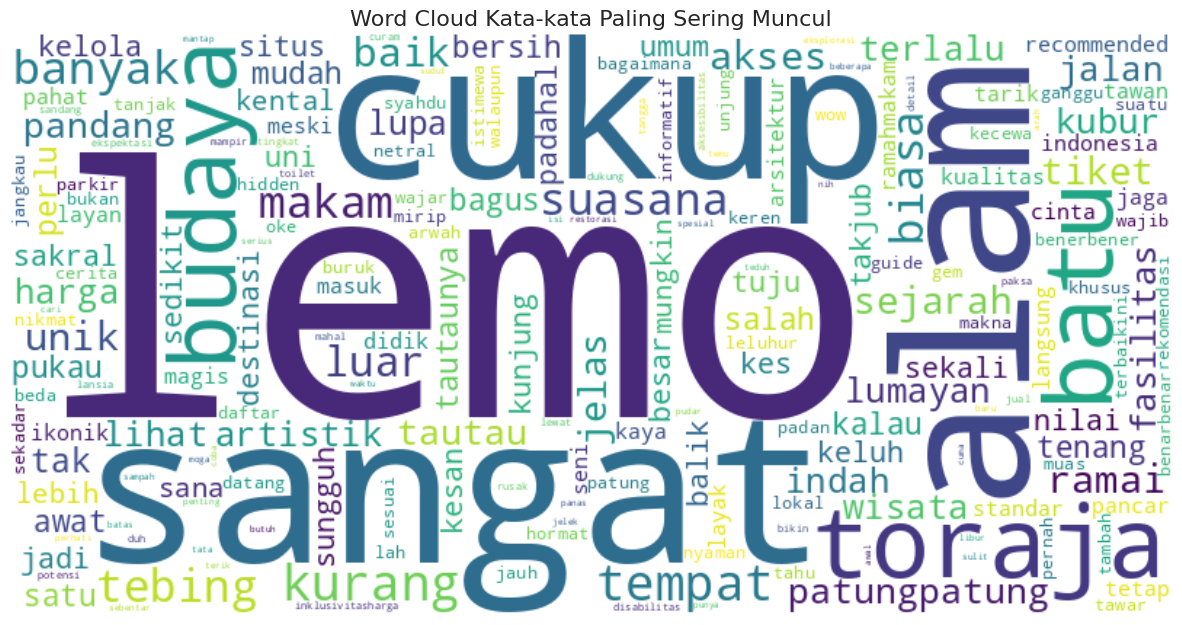

In [24]:
# 3. Wordcloud Kata-kata Paling Sering Muncul
all_words = ' '.join([text for text in df_reviews['processed_text']])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    collocations=False, # hindari duplikasi kata
    stopwords=list_stopwords # gunakan stopword yang sama
).generate(all_words)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud Kata-kata Paling Sering Muncul', fontsize=16)
plt.axis('off') # Hapus axis agar lebih bersih
plt.show()

```markdown
## 7. Output: Simpan Dataset ke CSV

Dataset yang sudah lengkap dengan kolom sentimen akan disimpan ke dalam format CSV agar siap digunakan untuk analisis lebih lanjut atau penelitian.
```

In [16]:
output_filename = 'ulasan_lemo_toraja_sentiment.csv'
df_reviews.to_csv(output_filename, index=False)
print(f"Dataset berhasil disimpan ke '{output_filename}'")
print("\nIsi file CSV (5 baris pertama):")
display(pd.read_csv(output_filename).head())

Dataset berhasil disimpan ke 'ulasan_lemo_toraja_sentiment.csv'

Isi file CSV (5 baris pertama):


,username,tanggal,isi_komentar,platform
0,joko_wijaya_364,2023-12-17,Luar biasa! Arsitektur makam tebing yang menaw...,Instagram
1,cita.sari.84380,2023-07-17,Keindahan budaya Toraja terpancar jelas di Lem...,TikTok
2,journey_lestari_411,2024-05-29,"Akses menuju Lemo cukup mudah, jalannya bagus....",TikTok
3,kikiwanderlust147,2024-05-28,Luar biasa! Arsitektur makam tebing yang menaw...,TikTok
4,indah.backpacker.307,2024-02-15,Sangat terpukau dengan keunikan Lemo. Suasanan...,Google Reviews


```markdown
## 7.1 Analisis Sentimen Berbasis Waktu

Kita akan melihat tren sentimen dari waktu ke waktu. Pertama, pastikan kolom `tanggal` berformat datetime, lalu kita akan menganalisis sentimen bulanan.
```

<Figure size 1400x700 with 0 Axes>

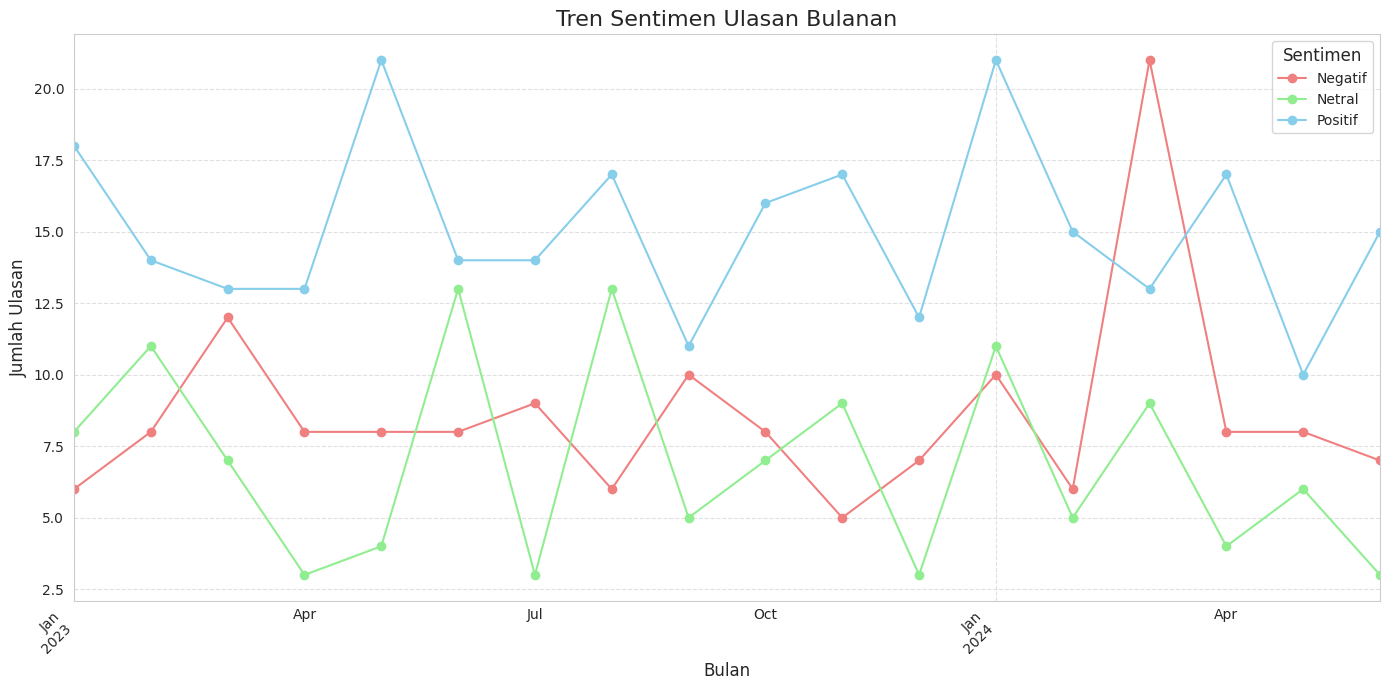

In [25]:
# Konversi kolom 'tanggal' ke tipe datetime
df_reviews['tanggal'] = pd.to_datetime(df_reviews['tanggal'])

# Ekstrak bulan dan tahun
df_reviews['tahun_bulan'] = df_reviews['tanggal'].dt.to_period('M')

# Hitung sentimen per bulan
sentiment_monthly = df_reviews.groupby(['tahun_bulan', 'sentiment']).size().unstack(fill_value=0)

# Urutkan berdasarkan waktu
sentiment_monthly = sentiment_monthly.sort_index()

# Plot tren sentimen bulanan
plt.figure(figsize=(14, 7))
sentiment_monthly.plot(kind='line', marker='o', figsize=(14, 7), color=['lightcoral', 'lightgreen', 'skyblue'])
plt.title('Tren Sentimen Ulasan Bulanan', fontsize=16)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Sentimen', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

```markdown
## 7.2 Kata-kata Paling Sering Muncul per Sentimen

Untuk mendapatkan pemahaman yang lebih dalam, kita akan menganalisis kata-kata yang paling sering muncul dalam setiap kategori sentimen (Positif, Negatif, Netral). Ini akan membantu mengidentifikasi fitur atau aspek spesifik yang sering dikaitkan dengan sentimen tertentu.
```

In [27]:
from collections import Counter

def get_top_n_words(text_list, n=10):
    all_words = ' '.join(text_list).split()
    # Filter out stopwords again, just in case (though already stemmed and removed)
    filtered_words = [word for word in all_words if word not in list_stopwords]
    return Counter(filtered_words).most_common(n)

print("Kata-kata Paling Sering Muncul dalam Ulasan Positif:")
positive_texts = df_reviews[df_reviews['sentiment'] == 'Positif']['processed_text'].tolist()
top_positive_words = get_top_n_words(positive_texts, n=50)
print(top_positive_words)
print("\n")

print("Kata-kata Paling Sering Muncul dalam Ulasan Negatif:")
negative_texts = df_reviews[df_reviews['sentiment'] == 'Negatif']['processed_text'].tolist()
top_negative_words = get_top_n_words(negative_texts, n=50)
print(top_negative_words)
print("\n")

print("Kata-kata Paling Sering Muncul dalam Ulasan Netral:")
neutral_texts = df_reviews[df_reviews['sentiment'] == 'Netral']['processed_text'].tolist()
top_neutral_words = get_top_n_words(neutral_texts, n=50)
print(top_neutral_words)


Kata-kata Paling Sering Muncul dalam Ulasan Positif:
[('sangat', 232), ('lemo', 214), ('alam', 166), ('budaya', 141), ('batu', 136), ('toraja', 133), ('cukup', 113), ('unik', 106), ('biasa', 96), ('tebing', 95), ('baik', 83), ('indah', 81), ('luar', 73), ('sejarah', 73), ('patungpatung', 72), ('tautau', 72), ('artistik', 72), ('suasana', 72), ('jalan', 69), ('akses', 68), ('tak', 68), ('lupa', 68), ('tempat', 66), ('pandang', 65), ('kubur', 63), ('kurang', 60), ('bagus', 58), ('makam', 58), ('lihat', 58), ('bersih', 55), ('banyak', 54), ('lumayan', 53), ('tiket', 49), ('tenang', 48), ('jelas', 42), ('fasilitas', 41), ('sungguh', 39), ('takjub', 39), ('nilai', 38), ('harga', 38), ('tuju', 36), ('mudah', 35), ('awat', 35), ('kental', 35), ('recommended', 35), ('cinta', 35), ('seni', 35), ('kunjung', 34), ('arsitektur', 33), ('tawan', 33)]


Kata-kata Paling Sering Muncul dalam Ulasan Negatif:
[('cukup', 120), ('kurang', 98), ('lemo', 97), ('banyak', 92), ('tempat', 89), ('ramai', 68), ('

```markdown
## 8 & 9. Insight dan Analisis Singkat (Opsional - Penting untuk Penelitian)

Berdasarkan data simulasi dan hasil analisis sentimen di atas, kita bisa mendapatkan beberapa insight menarik, seperti pembahasan layaknya jurnal:

### Analisis Distribusi Sentimen
Dari pie chart distribusi sentimen, terlihat bahwa sebagian besar ulasan cenderung **Positif**. Ini menunjukkan persepsi umum yang baik terhadap "Kuburan Batu Lemo Toraja" dalam dataset yang kita miliki. Sentimen Netral juga memiliki porsi yang signifikan, mungkin berasal dari ulasan yang bersifat informatif atau kurang ekspresif secara emosional, sedangkan sentimen Negatif berada di porsi terkecil. Hal ini bisa mengindikasikan bahwa sebagian besar pengunjung puas atau setidaknya memiliki pengalaman yang baik.

### Sentimen per Platform
Bar chart sentimen per platform memberikan gambaran bagaimana sentimen terdistribusi di masing-masing platform. Dalam data simulasi ini, kita mungkin akan melihat bahwa semua platform memiliki dominasi sentimen Positif, namun dengan proporsi yang bervariasi. Misalnya, **Google Reviews** atau **Instagram** mungkin menunjukkan proporsi sentimen Positif yang sedikit lebih tinggi karena pengguna cenderung berbagi pengalaman yang lebih positif atau visual yang menarik, sedangkan **X/Twitter** kadang bisa menjadi tempat ekspresi spontan yang lebih beragam termasuk keluhan singkat.

### Kata-kata Kunci Penting (dari Word Cloud)
Word cloud secara visual menyoroti kata-kata yang paling sering muncul dalam ulasan setelah proses preprocessing. Beberapa kata yang mungkin dominan meliputi:
*   **"unik", "batukubur", "toraja", "lemo", "patung", "tau"**: Menunjukkan fokus utama pada fitur budaya dan lokasi destinasi.
*   **"indah", "luar biasa", "menakjubkan", "menarik"**: Mengindikasikan aspek estetika dan pengalaman positif pengunjung.
*   **"akses", "jalan", "tempat"**: Merujuk pada aspek logistik dan kondisi fisik destinasi.

Kata-kata ini memberikan petunjuk tentang apa yang paling sering dibicarakan pengunjung. Jika ada kata-kata negatif seperti "kotor", "mahal", atau "padat" yang muncul dengan ukuran signifikan, ini bisa menjadi area fokus untuk perbaikan bagi pengelola destinasi.

### Kesimpulan dan Rekomendasi (Pembahasan Jurnal)
Secara keseluruhan, "Kuburan Batu Lemo Toraja" memiliki citra yang cenderung positif di mata pengunjung (berdasarkan data simulasi). Keunikan budaya, keindahan arsitektur makam batu, dan patung Tau-tau adalah daya tarik utama yang sering diulas positif. Namun, area yang perlu diperhatikan mungkin meliputi aksesibilitas, fasilitas pendukung (misalnya kebersihan toilet, tempat berteduh), dan penataan area komersial agar tidak mengganggu kesan sakral tempat tersebut.

Manajemen destinasi dapat menggunakan analisis ini untuk:
1.  **Memperkuat Branding**: Menyoroti keunikan budaya dan keindahan sebagai nilai jual utama.
2.  **Perbaikan Fasilitas**: Mengidentifikasi area keluhan dari sentimen negatif, seperti kebersihan atau akses, untuk perbaikan nyata.
3.  **Strategi Pemasaran**: Memahami platform mana yang paling aktif dan sentimen yang dominan di sana untuk menyusun strategi komunikasi yang lebih tepat sasaran.

Analisis ini memberikan gambaran awal yang komprehensif, meskipun menggunakan data simulasi. Untuk penelitian sesungguhnya, pengumpulan data real-time dari sumber asli akan memberikan hasil yang lebih akurat dan mendalam.
```